## Imports and Global Variables

In [270]:
import numpy as np
import cv2
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt

input_folder_path = "../media/input"
output_folder_path = "../media/output"
epsilon = 1e-10

# NOTE: Please always maintain the order of T, N, D while processing as well as passing parameters to functions

## Reading Input Image and Feature Maps

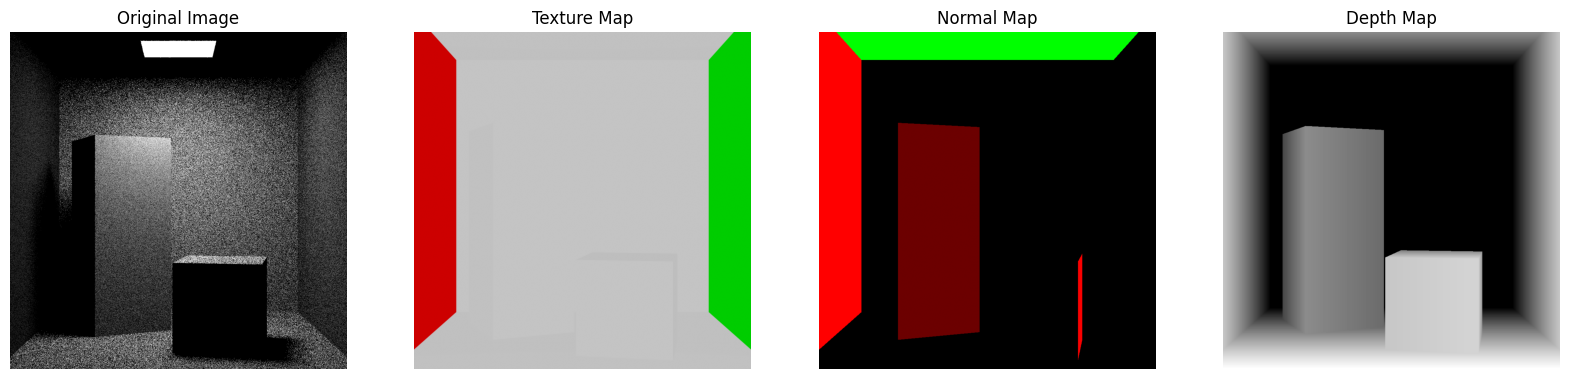

In [271]:
a = 1024 # Dimension of image
n = 10  # Sampling Rate

# Note: We are resizing the images to 200x200 for faster processing (will remove later when everything is working)
noisy_image = cv2.resize(cv2.imread(input_folder_path + f"/cuboids/{n}.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0       # Noisy Image
noisy_image_bgr = cv2.resize(cv2.imread(input_folder_path + "/cuboids/10.png"), (a, a))
noisy_image_rgb = cv2.cvtColor(noisy_image_bgr, cv2.COLOR_BGR2RGB) / 255.0

texture_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/texture.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0   # Texture Map
texture_map_bgr = cv2.resize(cv2.imread(input_folder_path + "/cuboids/texture.png"), (a, a))
texture_map_rgb = cv2.cvtColor(texture_map_bgr, cv2.COLOR_BGR2RGB) / 255.0

normal_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/normal.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0     # Normal Map
normal_map_bgr = cv2.resize(cv2.imread(input_folder_path + "/cuboids/normal.png"), (a, a))
normal_map_rgb = cv2.cvtColor(normal_map_bgr, cv2.COLOR_BGR2RGB) / 255.0

depth_map = cv2.resize(cv2.imread(input_folder_path + "/cuboids/depth.png", cv2.IMREAD_GRAYSCALE), (a, a)) / 255.0       # Depth Map

# Plotting the image and feature maps
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(noisy_image, cmap='gray')
axs[0].set_title("Original Image")
axs[0].axis('off')

axs[1].imshow(texture_map_rgb)
axs[1].set_title("Texture Map")
axs[1].axis('off')

axs[2].imshow(normal_map_rgb)
axs[2].set_title("Normal Map")
axs[2].axis('off')

axs[3].imshow(depth_map, cmap='gray')
axs[3].set_title("Depth Map")
axs[3].axis('off')

plt.show()

## Feature Maps Prefiltering

In [272]:
def sobel_gradient(image):
    """Calculate gradient magnitude using Sobel operator."""
    Gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal gradients
    Gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Vertical gradients
    gradient_magnitude = np.sqrt(Gx**2 + Gy**2)
    return gradient_magnitude

def guided_image_filter(I, P, radius=7, eps=0.001):
    """Apply guided image filtering."""
    mean_I = cv2.boxFilter(I, -1, (radius, radius))
    mean_P = cv2.boxFilter(P, -1, (radius, radius))
    mean_I_P = cv2.boxFilter(I * P, -1, (radius, radius))
    cov_I_P = mean_I_P - mean_I * mean_P
    
    mean_II = cv2.boxFilter(I * I, -1, (radius, radius))
    var_I = mean_II - mean_I * mean_I
    
    a = cov_I_P / (var_I + eps)
    b = mean_P - a * mean_I
    
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))
    
    output = mean_a * I + mean_b
    return output

def prefilter_features(texture_map, normal_map, depth_map):
    """Prefilter noisy features using the guided image filter."""
    # Normalise the normal map before calculating the gradients
    # texture_map = texture_map / 255.0
    # normal_map = normal_map / 255.0
    # normal_map_x = normal_map[:, :, 0] / 255.0
    # normal_map_y = normal_map[:, :, 1] / 255.0
    # normal_map_z = normal_map[:, :, 2] / 255.0
    # depth_map = depth_map / 255.0

    # Calculate gradients for each feature map
    gradient_texture = sobel_gradient(texture_map)
    gradient_normal = sobel_gradient(normal_map)
    # gradient_normal_x = sobel_gradient(normal_map_x)
    # gradient_normal_y = sobel_gradient(normal_map_y)
    # gradient_normal_z = sobel_gradient(normal_map_z)
    gradient_depth = sobel_gradient(depth_map)
    
    # Combine gradients to get a robust guidance image
    combined_gradient = np.maximum.reduce([gradient_texture, gradient_normal, gradient_depth])
    # combined_gradient = np.maximum.reduce([gradient_texture, gradient_normal_x, gradient_normal_y, gradient_normal_z, gradient_depth])
    
    # Filter each feature map using the guided image filter
    filtered_texture = np.clip(guided_image_filter(combined_gradient, texture_map), 0, 1)
    filtered_normal = np.clip(guided_image_filter(combined_gradient, normal_map), 0, 1)
    # filtered_normal_x = np.clip(guided_image_filter(combined_gradient, normal_map_x), 0, 1)
    # filtered_normal_y = np.clip(guided_image_filter(combined_gradient, normal_map_y), 0, 1)
    # filtered_normal_z = np.clip(guided_image_filter(combined_gradient, normal_map_z), 0, 1)
    filtered_depth = np.clip(guided_image_filter(combined_gradient, depth_map), 0, 1)

    # Converting filters back to 0-255 range
    filtered_texture = (filtered_texture * 255).astype(np.uint8)
    filtered_normal = (filtered_normal * 255).astype(np.uint8)
    # filtered_normal_x = (filtered_normal_x * 255).astype(np.uint8)
    # filtered_normal_y = (filtered_normal_y * 255).astype(np.uint8)
    # filtered_normal_z = (filtered_normal_z * 255).astype(np.uint8)
    # filtered_normal = np.dstack((filtered_normal_x, filtered_normal_y, filtered_normal_z))
    filtered_depth = (filtered_depth * 255).astype(np.uint8)
    
    return combined_gradient, filtered_texture, filtered_normal, filtered_depth

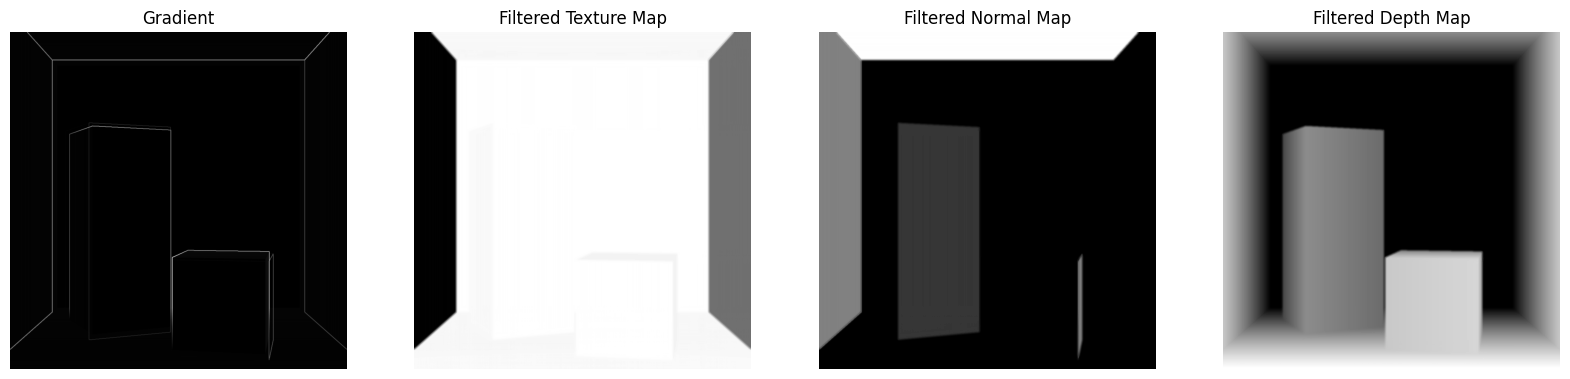

In [273]:
gradient_map, filtered_texture, filtered_normal, filtered_depth = prefilter_features(texture_map, normal_map, depth_map)

cv2.imwrite(output_folder_path + f"/gradient_map_{n}.png", (gradient_map * 255).astype(np.uint8))
cv2.imwrite(output_folder_path + f"/filtered_texture_map_{n}.png", filtered_texture)
cv2.imwrite(output_folder_path + f"/filtered_normal_map_{n}.png", filtered_normal)
cv2.imwrite(output_folder_path + f"/filtered_depth_map_{n}.png", filtered_depth)

# Plotting the image and prefiltered feature maps
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
axs[0].imshow(gradient_map, cmap='gray')
axs[0].set_title("Gradient")
axs[0].axis('off')

axs[1].imshow(filtered_texture, cmap='gray')
axs[1].set_title("Filtered Texture Map")
axs[1].axis('off')

axs[2].imshow(filtered_normal, cmap='gray')
axs[2].set_title("Filtered Normal Map")
axs[2].axis('off')

axs[3].imshow(filtered_depth, cmap='gray')
axs[3].set_title("Filtered Depth Map")
axs[3].axis('off')

plt.show()

## Cross Bilateral Filter

In [274]:
def feature_distance(f1, f2, grad_i, var_f1, var_f2):
    nr = np.linalg.norm(f1 - f2)**2
    dr = np.float32(var_f1)**2 + np.float32(var_f2)**2 + np.minimum(grad_i, 0.001) + epsilon
    dist = nr / dr
    return dist

# def calculate_single_channel_variance(image, kernel_size=3):
#     # Helper function to calculate sample variance
#     def sample_variance(window):
#         return np.var(window, ddof=1)  # Sample variance

#     # Calculate variance for the image
#     variance = generic_filter(image, sample_variance, size=kernel_size)
#     return variance

# def calculate_neighborhood_variances(texture_map, normal_map, depth_map, kernel_size=3):
#     # Calculate variance for the texture map
#     texture_variance = calculate_single_channel_variance(texture_map, kernel_size)

#     # Calculate variance for each component of the normal map
#     normal_variance = calculate_single_channel_variance(normal_map, kernel_size)
#     # normal_x_variance = calculate_single_channel_variance(normal_map[:, :, 0], kernel_size)
#     # normal_y_variance = calculate_single_channel_variance(normal_map[:, :, 1], kernel_size)
#     # normal_z_variance = calculate_single_channel_variance(normal_map[:, :, 2], kernel_size)

#     # Combine the variances of the normal components
#     # normal_variance = (normal_x_variance + normal_y_variance + normal_z_variance) / 3

#     # Calculate variance for the depth map
#     depth_variance = calculate_single_channel_variance(depth_map, kernel_size)

#     return texture_variance, normal_variance, depth_variance

# def calc_filter_weight(image, texture_map, normal_map, depth_map, texture_variance, normal_variance, depth_variance, grad, alpha, beta, gamma_t, gamma_d, gamma_n, i, j, x, y):
#     # H, W, C = image.shape
#     H, W = image.shape
#     spatial_coords = np.indices((H, W)).transpose(1, 2, 0)  # Pixel coordinates
    
#     # Spatial weight
#     spatial_weight = np.exp(-np.linalg.norm(spatial_coords[i, j] - spatial_coords[x, y])**2 / (2 * alpha[i, j]**2 + epsilon))

#     # Color weight
#     color_weight = np.exp(-np.linalg.norm(np.float32(image[i, j]) - np.float32(image[x, y]))**2 / (2 * beta[i, j]**2 + epsilon))

#     # Texture weight
#     texture_weight = np.exp(-feature_distance(np.float32(texture_map[i, j]), np.float32(texture_map[x, y]), grad[x, y], texture_variance[i, j], texture_variance[x, y])**2 / (2 * gamma_t[i, j]**2 + epsilon))

#     # Normal weight
#     normal_weight = np.exp(-feature_distance(np.float32(normal_map[i, j]), np.float32(normal_map[x, y]), grad[x, y], normal_variance[i, j], normal_variance[x, y])**2 / (2 * gamma_n[i, j]**2 + epsilon))
    
#     # Depth weight
#     depth_weight = np.exp(-feature_distance(np.float32(depth_map[i, j]), np.float32(depth_map[x, y]), grad[x, y], depth_variance[i, j], depth_variance[x, y])**2 / (2 * gamma_d[i, j]**2 + epsilon))

#     # Total weight
#     weight = spatial_weight * color_weight * texture_weight * depth_weight * normal_weight
#     return weight

In [275]:
import numpy as np
from scipy.ndimage import uniform_filter

def calculate_neighborhood_variances(texture_map, normal_map, depth_map):
    # Compute local variances using uniform filter (sliding window)
    texture_variance = uniform_filter(texture_map**2, size=3) - uniform_filter(texture_map, size=3)**2
    normal_variance = uniform_filter(normal_map**2, size=3) - uniform_filter(normal_map, size=3)**2
    depth_variance = uniform_filter(depth_map**2, size=3) - uniform_filter(depth_map, size=3)**2
    return texture_variance, normal_variance, depth_variance

def calc_filter_weight(image, texture_map, normal_map, depth_map, texture_variance, normal_variance, depth_variance, grad, alpha, beta, gamma_t, gamma_d, gamma_n):
    # Calculate weights for the entire image in one step
    diff_image = np.abs(image - uniform_filter(image, size=3))
    diff_texture = np.abs(texture_map - uniform_filter(texture_map, size=3))
    diff_normal = np.abs(normal_map - uniform_filter(normal_map, size=3))
    diff_depth = np.abs(depth_map - uniform_filter(depth_map, size=3))

    weight = np.exp(-alpha * diff_image**2 - beta * grad**2 - gamma_t * diff_texture**2 -
                    gamma_d * diff_depth**2 - gamma_n * diff_normal**2)
    return weight

def cross_bilateral_filter(image, texture_map, normal_map, depth_map, alpha, beta, gamma_t, gamma_d, gamma_n, grad):
    # Precompute neighborhood variances
    texture_variance, normal_variance, depth_variance = calculate_neighborhood_variances(texture_map, normal_map, depth_map)

    # Calculate filter weights
    weights = calc_filter_weight(image, texture_map, normal_map, depth_map, 
                                  texture_variance, normal_variance, depth_variance, grad, 
                                  alpha, beta, gamma_t, gamma_d, gamma_n)

    # Normalize weights
    weights_sum = uniform_filter(weights, size=3)
    weights_normalized = weights / (weights_sum)

    # Apply filtering
    filtered_image = uniform_filter(image * weights, size=3) / (weights_sum + 1e-6)
    return filtered_image


## Calculating Parameters

### Optimising $\alpha$ (Spatial Parameter)

In [276]:
# Values taken from research paper
alpha_vals = np.array([0.1 * np.ones(noisy_image.shape[:2]), 1 * np.ones(noisy_image.shape[:2]), 2 * np.ones(noisy_image.shape[:2]), 4 * np.ones(noisy_image.shape[:2]), 8 * np.ones(noisy_image.shape[:2])])
# alpha_vals = np.array([0.1 * np.ones(noisy_image.shape[:2])])

beta = 0 * np.ones(noisy_image.shape[:2])

# Keep gamma constant for calculation of alpha_optimal
gamma_t = 0.2 * np.ones(noisy_image.shape[:2])
gamma_d = 0.3 * np.ones(noisy_image.shape[:2])
gamma_n = 0.4 * np.ones(noisy_image.shape[:2])

import numpy as np
from scipy.ndimage import uniform_filter

def compute_bias_and_variance(image, texture_map, normal_map, depth_map, grad, alpha_vals, beta, gamma_t, gamma_n, gamma_d):
    H, W = image.shape[:2]
    biases = np.zeros((len(alpha_vals), H, W))
    variances = np.zeros((len(alpha_vals), H, W))

    for idx, alpha in enumerate(alpha_vals):
        filtered_image = cross_bilateral_filter(image, texture_map, normal_map, depth_map, 
                                                alpha, beta, gamma_t, gamma_n, gamma_d, grad)
        
        # Bias: Difference between filtered image and original
        biases[idx] = filtered_image - image

        # Variance: Weighted sum of neighborhood variance
        variance_map = uniform_filter(grad**2, size=3)  # Local variance estimation
        variances[idx] = alpha**2 * variance_map

    return biases, variances

def fit_curves(alpha_vals, biases, variances, n):
    # Fit curves across all pixels at once
    z = 1 / (alpha_vals**2 + 1e-6)  # Avoid divide by zero

    # Fit bias curve: bias = b0 + b1 * alpha
    b1 = np.sum((alpha_vals - alpha_vals.mean(axis=0)) * (biases - biases.mean(axis=0)), axis=0) / \
         np.sum((alpha_vals - alpha_vals.mean(axis=0))**2, axis=0)
    b0 = biases.mean(axis=0) - b1 * alpha_vals.mean(axis=0)

    # Fit variance curve: variance = v0 + v1 / alpha^2
    v1 = np.sum((z - z.mean(axis=0)) * (variances * n - (variances * n).mean(axis=0)), axis=0) / \
         np.sum((z - z.mean(axis=0))**2, axis=0)
    v0 = (variances * n).mean(axis=0) - v1 * z.mean(axis=0)

    return b0, b1, v0, v1

def calculate_optimal_alpha(b1, v1, n):
    # Compute alpha_opt directly using vectorized operations
    alpha_opt = np.power(np.abs(v1 / (2 * b1**2 * n + 1e-6)), 1/6)
    return np.clip(alpha_opt, 0.1, 8)  # Clamp alpha values to a reasonable range

# Main function
def calculate_optimal_spatial_parameter(image, texture_map, normal_map, depth_map, grad, n, alpha_vals, beta, gamma_t, gamma_n, gamma_d):
    # Step 1: Compute biases and variances
    biases, variances = compute_bias_and_variance(image, texture_map, normal_map, depth_map, 
                                                  grad, alpha_vals, beta, gamma_t, gamma_n, gamma_d)

    # Step 2: Fit parametric curves
    b0, b1, v0, v1 = fit_curves(alpha_vals, biases, variances, n)

    # Step 3: Compute alpha_opt
    alpha_opt = calculate_optimal_alpha(b1, v1, n)
    return alpha_opt

alpha_op = calculate_optimal_spatial_parameter(noisy_image, filtered_texture, filtered_normal, filtered_depth, gradient_map, n, alpha_vals, beta, gamma_t, gamma_n, gamma_d)

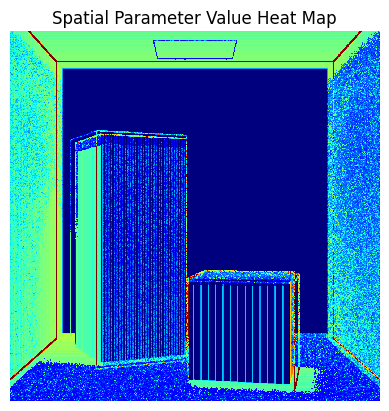

In [277]:
plt.imshow(alpha_op, cmap='jet', interpolation='nearest')
plt.axis('off')
plt.title("Spatial Parameter Value Heat Map")
plt.savefig(output_folder_path + f"/alpha_heatmap{10}.png", dpi=400)

## Optimising $\gamma$ (Feature Parameters)

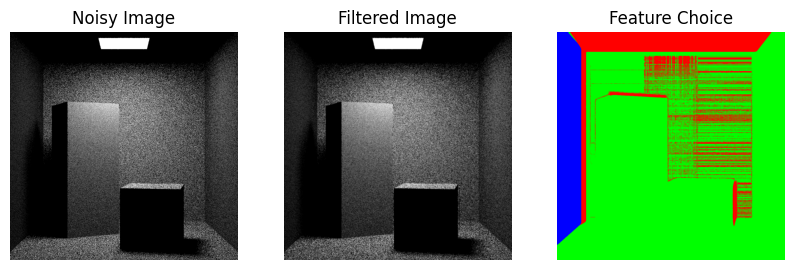

In [278]:
def calc_feature_parameters(image, texture_map, normal_map, depth_map, alpha_op, s_vals):
    guided_filtered_image_t = guided_image_filter(image, texture_map)
    guided_filtered_image_n = guided_image_filter(image, normal_map)
    guided_filtered_image_d = guided_image_filter(image, depth_map)

    lambda_t = np.abs(guided_filtered_image_t - image) / (image + epsilon)
    lambda_n = np.abs(guided_filtered_image_n - image) / (image + epsilon)
    lambda_d = np.abs(guided_filtered_image_d - image) / (image + epsilon)

    ref_image = np.zeros_like(image)

    # Create a boolean mask for each condition
    condition_t = (lambda_t < lambda_n) & (lambda_t < lambda_d)
    condition_n = (lambda_n < lambda_t) & (lambda_n < lambda_d)
    condition_d = ~(condition_t | condition_n)  # Remaining condition

    colored_image = np.zeros((lambda_t.shape[0], lambda_t.shape[1], 3), dtype=np.float32)

    # Assign colors based on conditions
    colored_image[condition_t] = [0, 0, 1]  # Blue for condition_t
    colored_image[condition_n] = [0, 1, 0]  # Green for condition_n
    colored_image[condition_d] = [1, 0, 0]  # Red for condition_d

    # Initialize ref_image with zeros or a suitable default value
    ref_image = np.zeros_like(guided_filtered_image_t)

    # Use the masks to assign values from the appropriate guided filtered images
    ref_image[condition_t] = guided_filtered_image_t[condition_t]
    ref_image[condition_n] = guided_filtered_image_n[condition_n]
    ref_image[condition_d] = guided_filtered_image_d[condition_d]

    errors = np.zeros((len(s_vals), image.shape[0], image.shape[1]))

    c_hat = []

    for idx, s in enumerate(s_vals):
        c_j_hat = cross_bilateral_filter(image, filtered_texture, filtered_normal, filtered_depth, alpha_op, beta, s, s, s, gradient_map)
        c_hat.append(c_j_hat)
        errors[idx] = (np.abs(c_j_hat - ref_image) ** 2) / (ref_image ** 2 + epsilon)

    return errors, colored_image, c_hat

def two_step_smoothening(image, errors, c_hat):
    l = errors.shape[0]  # Number of steps or levels in the process

    for j in range(l):
        errors[j] = guided_image_filter(errors[j], errors[j])  # Apply guidance on the error term
    
    binaries = list()
    for err in errors:
        min_err = np.min(err)
        binary = np.where(err < min_err + 1e10, 1, 0)
        binaries.append(binary)
    
    wei_j = list()
    for binary in binaries:
        wei_j.append(guided_image_filter(binary, binary))
    
    nr = np.zeros_like(image)
    dr = np.zeros_like(image)

    for idx, wei in enumerate(wei_j):
        nr += wei * c_hat[idx]
        dr += wei
    
    out_i = nr / (dr + epsilon)
    return out_i
            
s_vals = [0.25 * np.ones(noisy_image.shape[:2]), 0.6 * np.ones(noisy_image.shape[:2]), 0.8 * np.ones(noisy_image.shape[:2])]

errors, feature_choice_map, c_hat = calc_feature_parameters(noisy_image, filtered_texture, filtered_normal, filtered_depth, alpha_op, s_vals)

filtered_image = two_step_smoothening(noisy_image, errors, c_hat)

cv2.imwrite(output_folder_path + f"/filtered_{n}.png", (filtered_image * 255).astype(np.uint8))
cv2.imwrite(output_folder_path + f"/feature_choice_{n}.png", (feature_choice_map * 255).astype(np.uint8))

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(noisy_image, cmap='gray')
ax[0].set_title("Noisy Image")
ax[0].axis('off')

ax[1].imshow(filtered_image, cmap='gray')
ax[1].set_title("Filtered Image")
ax[1].axis('off')

ax[2].imshow(feature_choice_map)
ax[2].set_title("Feature Choice")
ax[2].axis('off')

plt.show()

## Saving the value of alpha for 50x50 cuboids image for future use

In [258]:
with open("alpha_value23323.txt", "w") as f:
    for i in range(alpha_op.shape[0]):
        for j in range(alpha_op.shape[1]):
            f.write(str(alpha_op[i, j]) + " ")

In [ ]:
# def read_alpha_values(file_path, shape):
#     with open(file_path, "r") as f:
#         values = np.array([float(val) for val in f.read().split()])
#     return values.reshape(shape)

# alpha_op = read_alpha_values("alpha_value.txt", noisy_image.shape)
# beta = 10000 * np.ones(noisy_image.shape[:2])
# gamma_t = 0.2 * np.ones(noisy_image.shape[:2])
# gamma_d = 0.3 * np.ones(noisy_image.shape[:2])
# gamma_n = 0.4 * np.ones(noisy_image.shape[:2])
# filtered_image = cross_bilateral_filter(noisy_image, filtered_texture, filtered_normal, filtered_depth, alpha_op * 500000, beta, gamma_t, gamma_d, gamma_n, gradient_map)

ValueError: cannot reshape array of size 2500 into shape (1024,1024)

## Removing Spike Noise

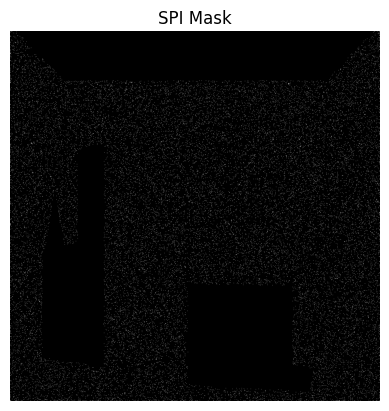

In [84]:
def calculate_spi_mask(image, gradient_image, kernel_size=3):
    gradient_image = gradient_image.astype(np.float32)
    image = image.astype(np.float32)
    
    pad_size = kernel_size // 2
    padded_image = np.pad(image, pad_size, mode='reflect')
    padded_gradient = np.pad(gradient_image, pad_size, mode='reflect')
    
    height, width = image.shape
    spi_mask = np.zeros_like(image, dtype=np.float32)
    
    for i in range(height):
        for j in range(width):
            # Extract the kernel
            kernel = padded_image[i:i + kernel_size, j:j + kernel_size]
            grad_kernel = padded_gradient[i:i + kernel_size, j:j + kernel_size]
            
            # Compute mean and standard deviation
            mean_i = np.mean(kernel)
            stdev_i = np.std(kernel)
            
            # Center pixel
            C_i = image[i, j]
            
            # Gradient at center pixel
            gra_i = gradient_image[i, j]
            
            # Compute SPI value
            spi_mask[i, j] = np.abs(mean_i - C_i) - max(gra_i, stdev_i)

            if spi_mask[i, j] > 0:
                spi_mask[i, j] = 1
            else:
                spi_mask[i, j] = 0
    
    return spi_mask

noisy_image = cv2.imread("../media/input/cuboids/1000.png", cv2.IMREAD_GRAYSCALE) / 255.0
gradient_image = sobel_gradient(noisy_image)
spi_mask = calculate_spi_mask(noisy_image, gradient_image)

plt.imshow(spi_mask, cmap='gray')
plt.axis('off')
plt.title("SPI Mask")
plt.show()